In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("micro_spending.csv")

print("First 5 rows:")
print(df.head())

First 5 rows:
         Date   Category  Amount Payment_Mode    Location
0  2026-04-01       Food      80          UPI     Canteen
1  2026-04-01  Transport      50         Cash         Bus
2  2026-04-02       Food     120          UPI  Restaurant
3  2026-04-02     Online      90         Card      Amazon
4  2026-04-03       Food      60          UPI     Canteen


In [5]:
print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          40 non-null     object
 1   Category      40 non-null     object
 2   Amount        40 non-null     int64 
 3   Payment_Mode  40 non-null     object
 4   Location      40 non-null     object
dtypes: int64(1), object(4)
memory usage: 1.7+ KB
None

Summary Statistics:
           Amount
count   40.000000
mean    99.750000
std     69.577019
min     30.000000
25%     53.750000
50%     75.000000
75%    105.000000
max    300.000000

Missing Values:
Date            0
Category        0
Amount          0
Payment_Mode    0
Location        0
dtype: int64


In [6]:
df.drop_duplicates(inplace=True)

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])


In [7]:
df['Day'] = df['Date'].dt.day_name()

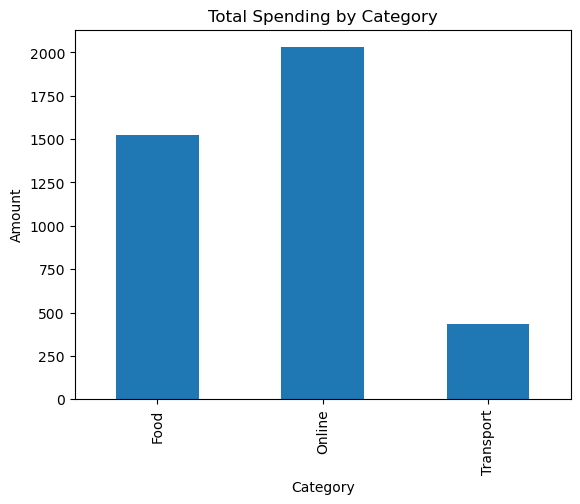

In [8]:
plt.figure()
df.groupby('Category')['Amount'].sum().plot(kind='bar')
plt.title("Total Spending by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.show()


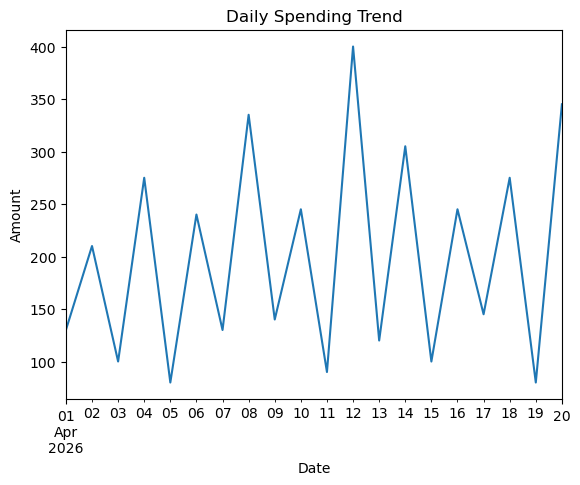

In [9]:
plt.figure()
df.groupby('Date')['Amount'].sum().plot(kind='line')
plt.title("Daily Spending Trend")
plt.xlabel("Date")
plt.ylabel("Amount")
plt.show()

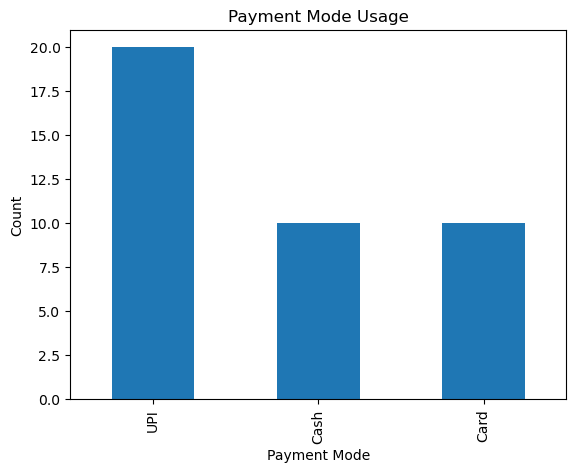

In [10]:
plt.figure()
df['Payment_Mode'].value_counts().plot(kind='bar')
plt.title("Payment Mode Usage")
plt.xlabel("Payment Mode")
plt.ylabel("Count")
plt.show()

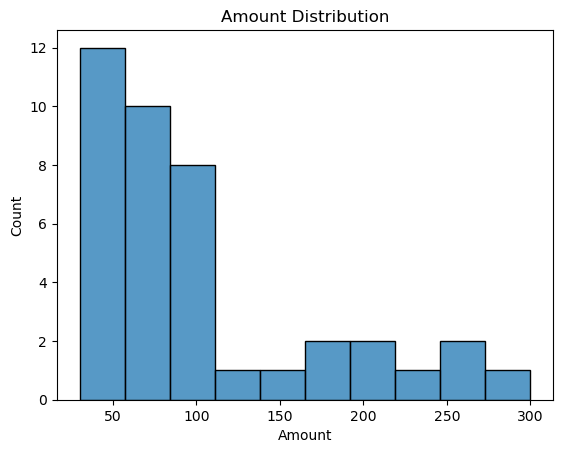

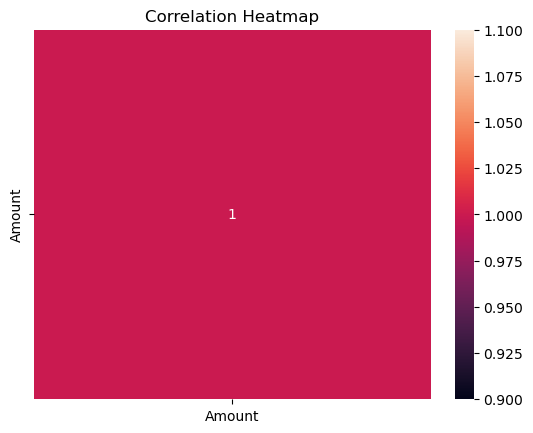

In [11]:
plt.figure()
sns.histplot(df['Amount'], bins=10)
plt.title("Amount Distribution")
plt.show()

# 5. Correlation Heatmap
plt.figure()
sns.heatmap(df[['Amount']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [12]:
micro_spending = df[df['Amount'] < 100]

print("\nMicro Spending Count (<100):", len(micro_spending))

print("\nCategory-wise Micro Spending:")
print(micro_spending['Category'].value_counts())



Micro Spending Count (<100): 29

Category-wise Micro Spending:
Category
Food         18
Transport    10
Online        1
Name: count, dtype: int64


In [13]:

print("\n--- KEY INSIGHTS ---")

print("1. Total Spending by Category:")
print(df.groupby('Category')['Amount'].sum())

print("\n2. Most Used Payment Mode:")
print(df['Payment_Mode'].value_counts().idxmax())

print("\n3. Highest Spending Day:")
print(df.groupby('Date')['Amount'].sum().idxmax())


--- KEY INSIGHTS ---
1. Total Spending by Category:
Category
Food         1525
Online       2030
Transport     435
Name: Amount, dtype: int64

2. Most Used Payment Mode:
UPI

3. Highest Spending Day:
2026-04-12 00:00:00
